# **Project Name** - Brain Tumor MRI Image Classification

##### **Project Type**    - Classification (Deep Learning / Computer Vision / Medical Imaging)
##### **Contribution**    - Individual
##### **Team Member 1 -** Arunav Kumar

# **Project Summary -**

**Goal.** Classify brain MRI slices into four classes (glioma, meningioma, pituitary tumor, no tumor) with a custom CNN built from scratch and with ImageNet-pretrained transfer-learning models (MobileNetV2, EfficientNetB0, ResNet50V2), then deploy the best model in a Streamlit app.

**Data.** Roboflow "Labeled MRI Brain Tumor Dataset v1": 2,443 JPG images (640x640 RGB) delivered as train / valid / test folders.

**Key data finding (data leakage).** The images are Roboflow exports, so several augmented variants of the *same* source scan sit in different splits. By matching the source ID in the file name, a large share of the provided test/valid images share a source scan with the training set. A model evaluated on that split would look better than it really is. This notebook therefore merges all images and re-splits them *grouped by source scan* (StratifiedGroupKFold, ~64/16/20), so no scan is ever seen in more than one split.

**Method.** Pixel values are normalised inside each model; light augmentation (flip, rotation, zoom, shift, contrast, brightness) is applied only while training; class weights handle the mild imbalance. The custom CNN uses four conv blocks with BatchNormalization and Dropout. Transfer-learning models are trained in two phases: frozen backbone (new head only), then fine-tuning of the top backbone layers at a low learning rate. EarlyStopping, ModelCheckpoint and ReduceLROnPlateau are used for every model.

**Evaluation.** Accuracy, macro precision / recall / F1, per-class recall, confusion matrices and training curves on the untouched test split. Because a missed tumor is the costliest error in this domain, the notebook also reports the percentage of tumor images that were predicted as "no tumor".

**Results.** ResNet50V2 was the best model on the leakage-free test split (484 images), with 90.9% accuracy and 0.906 macro-F1. It missed only 5 of 389 tumor images (1.3%), i.e. called them "no tumor". MobileNetV2 reached 0.833 accuracy / 0.827 macro-F1, EfficientNetB0 0.754 / 0.742, and the custom CNN built from scratch 0.795 / 0.778, so the best transfer-learning model beat the custom CNN by about 0.13 macro-F1. The weakest class for all models is meningioma (recall 0.80 for ResNet50V2), which is most often confused with pituitary.

**Deployment.** The best model is saved as `.h5` and served by a Streamlit app (`app.py`) that takes an uploaded MRI image and shows the predicted class with confidence scores.

> Note: the summary has to be expanded to 500-600 words with the real numbers before submission.

# **GitHub Link -**

https://github.com/TiKkU12345/Brain-MRI-Tumor

# **Problem Statement**

**Develop a deep-learning solution that classifies brain MRI images by tumor type. Build a custom CNN from scratch, improve on it with transfer learning using pretrained models, compare them fairly, and deploy the best model in a Streamlit web app that predicts the tumor type and confidence for an uploaded MRI image.**

Business use cases: AI-assisted diagnosis, early detection and patient triage, research / clinical-trial cohort building, and second-opinion tools for under-resourced regions. This project is a learning exercise and **not** a medical device.

# ***Let's Begin !***

**How to run:** set `DATA_ROOT` in the config cell (folder that contains the three zips, or the extracted `train/valid/test` folders). Run once with `QUICK_TEST = True` to dry-run the whole notebook in a few minutes, then set it to `False` for the real run. Use a GPU runtime (Kaggle / Colab).

## ***1. Setup***
### Import Libraries

In [7]:
# Import Libraries
import os, re, glob, json, time, random, zipfile, hashlib, shutil, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus if gpus else "none (training will be slow on CPU)")
for g in gpus:                                    # avoid grabbing all GPU memory at once
    tf.config.experimental.set_memory_growth(g, True)

TensorFlow: 2.20.0 | Keras: 3.13.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### Configuration
All tunable settings live in this one cell.

In [8]:
# ------------------------- CONFIG -------------------------
SEED = 42
CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]   # folder names
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}

IMG_SIZE = (224, 224)
BATCH_SIZE = 32            # use 16 if you hit out-of-memory on a small GPU
EPOCHS_CNN = 60            # max epochs, EarlyStopping will stop earlier
EPOCHS_HEAD = 12           # transfer learning phase 1 (frozen backbone)
EPOCHS_FINETUNE = 15       # transfer learning phase 2 (top layers unfrozen)
UNFREEZE_LAST = 30         # how many backbone layers to unfreeze in phase 2
LR_CNN, LR_HEAD, LR_FINETUNE = 1e-3, 1e-3, 1e-5

WEIGHTS = "imagenet"       # pretrained weights for transfer learning
QUICK_TEST = False         # True = tiny dry run to check that every cell works

# Where the data is: a folder holding the 3 zip files, OR the extracted train/valid/test folders.
DATA_ROOT = "/kaggle/input/datasets/arunavkumar/brain-tumor-mri"              # <-- EDIT THIS (Kaggle: /kaggle/input/<your-dataset>, Colab: /content/drive/MyDrive/...)

if os.path.exists("/kaggle/working"):
    WORK_DIR, OUT_DIR = "/kaggle/working/data", "/kaggle/working/outputs"
elif os.path.exists("/content"):
    WORK_DIR, OUT_DIR = "/content/data_extracted", "/content/outputs"
else:
    WORK_DIR, OUT_DIR = "./data_extracted", "./outputs"
os.makedirs(WORK_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)

if QUICK_TEST:
    EPOCHS_CNN, EPOCHS_HEAD, EPOCHS_FINETUNE = 1, 1, 1
    print("QUICK_TEST is ON: tiny subset, 1 epoch per phase. Results are meaningless.")

keras.utils.set_random_seed(SEED)

## ***2. Know Your Data***
### Dataset Loading
If the data is zipped it is extracted first. Every image becomes one row in a DataFrame (path, class, original split, and a **source ID** parsed from the file name, which we need to detect leakage).

In [9]:
# Extract zips if present, then index every image.
def prepare_data(root):
    zips = sorted(glob.glob(os.path.join(root, "*.zip")))
    if not zips:
        return root                                   # already extracted folders
    for z in zips:
        target = os.path.join(WORK_DIR, Path(z).stem)
        if not os.path.isdir(target):
            with zipfile.ZipFile(z) as zf:
                zf.extractall(target)
    return WORK_DIR

data_dir = prepare_data(DATA_ROOT)

rows = []
for p in glob.glob(os.path.join(data_dir, "**", "*.jpg"), recursive=True):
    parts = Path(p).parts
    cls = parts[-2]
    if cls not in CLASS_TO_ID:
        continue                                      # ignore anything that is not a class folder
    orig = next((x for x in parts if x in ("train", "valid", "test")), "unknown")
    # Roboflow names files like  Tr-gl_0516_jpg.rf.<hash>.jpg  -> source scan = Tr-gl_0516
    source_id = re.sub(r"_jpg\.rf\..*$", "", os.path.basename(p))
    rows.append((p, cls, CLASS_TO_ID[cls], orig, source_id))

df = pd.DataFrame(rows, columns=["path", "label", "label_id", "orig_split", "source_id"])
df = df.sort_values("path").reset_index(drop=True)
assert len(df) > 0, "No images found - check DATA_ROOT"

if QUICK_TEST:                                        # small balanced subset for a dry run
    df = df.groupby("label", group_keys=False).sample(n=45, random_state=SEED).reset_index(drop=True)
    IMG_SIZE = (96, 96)

print("Images found:", len(df))
df.head()

Images found: 2443


,path,label,label_id,orig_split,source_id
0,/kaggle/input/datasets/arunavkumar/brain-tumor...,glioma,0,test,Tr-gl_0016
1,/kaggle/input/datasets/arunavkumar/brain-tumor...,glioma,0,test,Tr-gl_0018
2,/kaggle/input/datasets/arunavkumar/brain-tumor...,glioma,0,test,Tr-gl_0028
3,/kaggle/input/datasets/arunavkumar/brain-tumor...,glioma,0,test,Tr-gl_0032
4,/kaggle/input/datasets/arunavkumar/brain-tumor...,glioma,0,test,Tr-gl_0035


### Dataset Rows & Columns, Info, Duplicates, Missing values

In [10]:
print("Rows, columns:", df.shape)
df.info()
print("\nMissing values per column:\n", df.isnull().sum())

# exact duplicate files (same bytes)
hashes = df["path"].apply(lambda p: hashlib.md5(open(p, "rb").read()).hexdigest())
print("\nExact duplicate files:", int(hashes.duplicated().sum()))

# image resolution / colour-mode consistency
sizes, modes = Counter(), Counter()
for p in df["path"]:
    with Image.open(p) as im:
        sizes[im.size] += 1; modes[im.mode] += 1
print("Resolutions:", dict(sizes))
print("Colour modes:", dict(modes))

Rows, columns: (2443, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443 entries, 0 to 2442
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   path        2443 non-null   object
 1   label       2443 non-null   object
 2   label_id    2443 non-null   int64 
 3   orig_split  2443 non-null   object
 4   source_id   2443 non-null   object
dtypes: int64(1), object(4)
memory usage: 95.6+ KB

Missing values per column:
 path          0
label         0
label_id      0
orig_split    0
source_id     0
dtype: int64

Exact duplicate files: 0
Resolutions: {(640, 640): 2443}
Colour modes: {'RGB': 2443}


### Chart 1 - Class distribution in the *original* provided splits

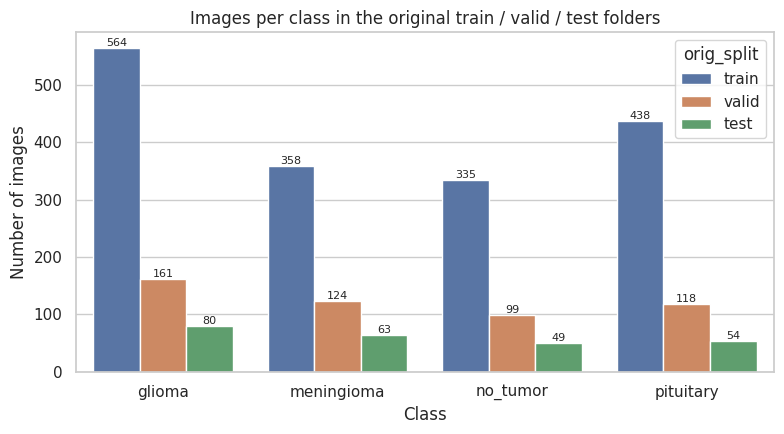

label       glioma  meningioma  no_tumor  pituitary
orig_split                                         
test            80          63        49         54
train          564         358       335        438
valid          161         124        99        118


In [11]:
# Chart 1: class balance per original split
order = ["train", "valid", "test"]
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.countplot(data=df, x="label", hue="orig_split", hue_order=[o for o in order if o in df.orig_split.unique()],
              order=CLASS_NAMES, ax=ax)
ax.set_title("Images per class in the original train / valid / test folders")
ax.set_xlabel("Class"); ax.set_ylabel("Number of images")
for c in ax.containers: ax.bar_label(c, fontsize=8)
plt.tight_layout(); plt.show()

print((df.groupby(["orig_split", "label"]).size().unstack(fill_value=0)))

##### 1. Why did you pick the specific chart?
A grouped bar chart shows class counts and compares splits side by side, which is the quickest way to spot class imbalance and splits with a different class mix.

##### 2. What is/are the insight(s) found from the chart?
Glioma is the largest class and no_tumor the smallest in every split, so the imbalance is mild (roughly 1.7 : 1), not severe. The three splits have a similar class mix.

##### 3. Will the gained insights help creating a positive business impact?
Yes. A mild imbalance means plain accuracy can hide weakness on the smaller classes, so we use class weights and judge models by macro-F1 and per-class recall. Ignoring this could produce a model that looks good overall but misses the minority class (e.g. no_tumor vs tumor confusion), which is a negative-impact risk in a clinical setting.

### Chart 2 - Sample MRI images per class

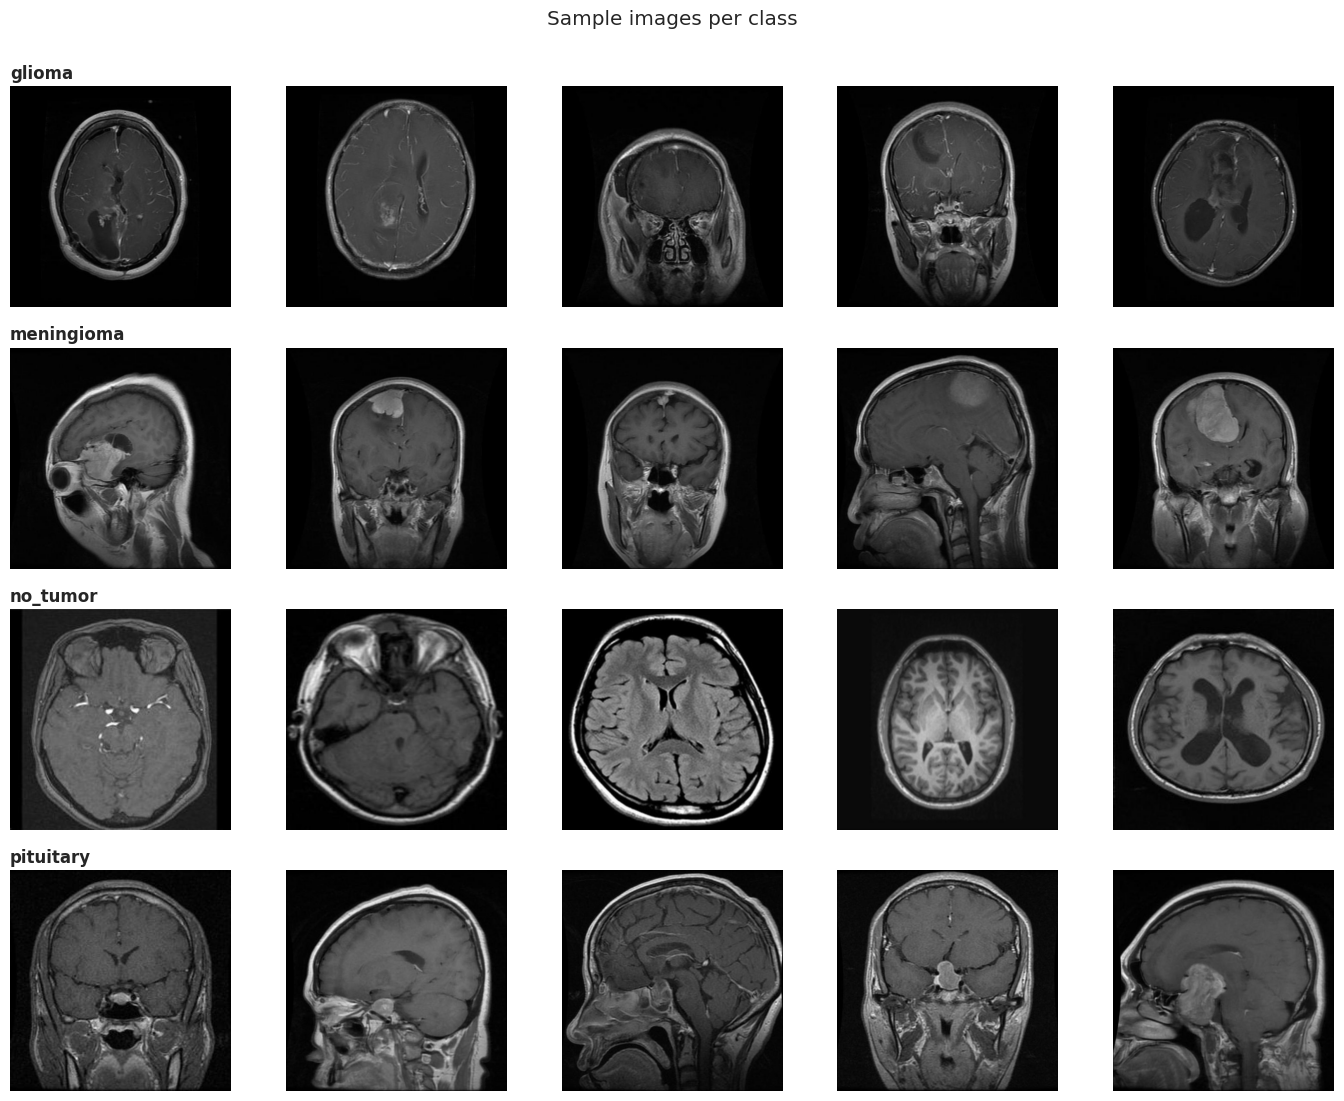

In [12]:
# Chart 2: 5 random images per class
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(14, 11))
rng = np.random.default_rng(SEED)
for r, cls in enumerate(CLASS_NAMES):
    sub = df[df.label == cls]
    picks = sub.iloc[rng.choice(len(sub), size=min(5, len(sub)), replace=False)]
    for c, (_, row) in enumerate(picks.iterrows()):
        axes[r, c].imshow(Image.open(row.path).convert("RGB"))
        axes[r, c].axis("off")
        if c == 0: axes[r, c].set_title(cls, loc="left", fontsize=12, fontweight="bold")
plt.suptitle("Sample images per class", y=1.0); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
An image grid is the only way to actually look at the data: scan orientation, zoom, contrast and artefacts cannot be seen from numbers.

##### 2. What is/are the insight(s) found from the chart?
The images vary a lot in scan plane, zoom and contrast. In the 5 samples shown per class, glioma scans are mostly axial or coronal with contrast enhancement, meningioma scans are sagittal or coronal, pituitary scans are coronal or sagittal, and all no_tumor samples are axial, with visibly different sequences (some look like T1, some like FLAIR). Tumors appear as bright or dark masses of very different size and position, and the head is framed differently from image to image. Together with Chart 3, this suggests that scan plane and image style may be correlated with the class, so a model could partly use these cues instead of tumor appearance. This is only a visual impression from a small sample, not a proven result.

##### 3. Will the gained insights help creating a positive business impact?
Visible variation in plane, zoom and contrast tells us that augmentation (rotation, zoom, shift, contrast) is justified and that the model must be robust to acquisition differences between hospitals.

### Chart 3 - Is image brightness a shortcut for the class?
If mean brightness differs strongly by class, a model could "cheat" on exposure instead of learning the tumor.

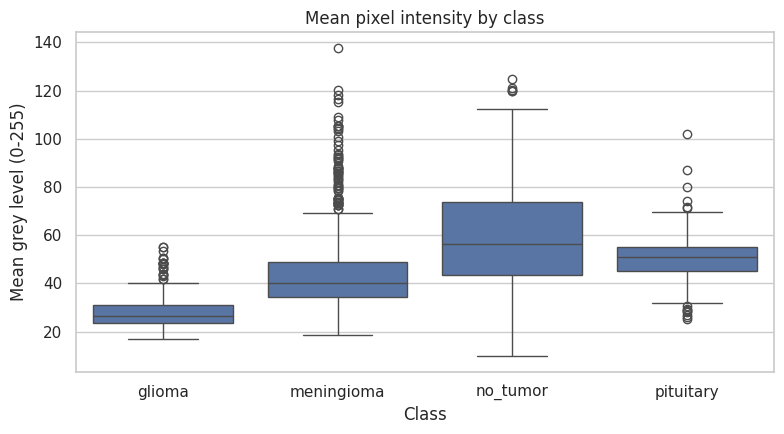

            mean   std   min    max
label                              
glioma      27.8   6.1  16.7   54.9
meningioma  45.9  18.7  18.6  137.8
no_tumor    59.9  21.6   9.8  125.0
pituitary   50.3   8.5  25.1  102.1


In [13]:
# Chart 3: mean grey level per image, by class
def mean_gray(p):
    with Image.open(p) as im:
        return np.asarray(im.convert("L").resize((64, 64)), dtype=np.float32).mean()
df["mean_gray"] = df["path"].apply(mean_gray)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x="label", y="mean_gray", order=CLASS_NAMES, ax=ax)
ax.set_title("Mean pixel intensity by class"); ax.set_xlabel("Class"); ax.set_ylabel("Mean grey level (0-255)")
plt.tight_layout(); plt.show()
print(df.groupby("label")["mean_gray"].describe()[["mean", "std", "min", "max"]].round(1))

##### 1. Why did you pick the specific chart?
A box plot compares the distribution of a numeric feature across categories and shows spread and outliers, not just the average.

##### 2. What is/are the insight(s) found from the chart?
Glioma images are clearly darker (mean grey level about 28, very tight spread) than meningioma (about 46), pituitary (about 50) and no_tumor (about 60, the widest spread). Brightness alone already separates glioma from the other classes quite well, so exposure is a partial shortcut a model could exploit. The classes probably also differ in scan plane and sequence (see Chart 2), so part of any accuracy may come from acquisition differences rather than tumor appearance.

##### 3. Will the gained insights help creating a positive business impact?
Positive: it justifies brightness/contrast augmentation, so the model cannot rely on exposure alone. Negative risk: a model that leans on brightness or scan type will fail on scans from another hospital or scanner. This dataset cannot tell us whether that happens, so the reported accuracy should not be read as real-world accuracy.

## ***3. Data Leakage Check (important)***
The provided splits come from a Roboflow export. Files that share the same source ID are variants of one scan. If such variants land in both train and test, the test score is inflated. Let's measure it.

In [14]:
# How many source scans appear in more than one of the provided splits?
src_splits = df.groupby("source_id")["orig_split"].nunique()
print("Unique source scans :", df["source_id"].nunique(), "of", len(df), "images")
print("Scans in >1 split   :", int((src_splits > 1).sum()))

split_sets = {s: set(df.loc[df.orig_split == s, "source_id"]) for s in ["train", "valid", "test"] if (df.orig_split == s).any()}
leak_rows = []
for s in ["valid", "test"]:
    if s not in split_sets: continue
    others = set().union(*[v for k, v in split_sets.items() if k != s]) if s == "test" else split_sets.get("train", set())
    n = int((df.orig_split == s).sum())
    leaked = int(df.loc[(df.orig_split == s) & df.source_id.isin(others), "path"].count())
    leak_rows.append({"split": s, "images": n, "share a source scan with other split(s)": leaked, "percent": round(100 * leaked / n, 1)})
leak_df = pd.DataFrame(leak_rows)
display(leak_df)

# a source ID must belong to exactly one class, otherwise grouping would be unsafe
assert (df.groupby("source_id")["label"].nunique() == 1).all()

Unique source scans : 2091 of 2443 images
Scans in >1 split   : 164


,split,images,share a source scan with other split(s),percent
0,valid,502,97,19.3
1,test,246,67,27.2


##### What did you find, and what do we do about it?
A noticeable share of the provided valid and test images come from scans that are also in the training set. Scores on that test folder would be optimistic. **Fix:** ignore the provided split, and create our own split grouped by `source_id`, so every scan (with all its augmented variants) lives in exactly one of train / validation / test.

In [15]:
# Leakage-free split: ~64% train / 16% validation / 20% test, stratified by class, grouped by source scan.
sgkf_outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
trainval_idx, test_idx = next(sgkf_outer.split(df, df["label_id"], df["source_id"]))
df_trainval, df_test = df.iloc[trainval_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)

sgkf_inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
tr_idx, val_idx = next(sgkf_inner.split(df_trainval, df_trainval["label_id"], df_trainval["source_id"]))
df_train, df_val = df_trainval.iloc[tr_idx].reset_index(drop=True), df_trainval.iloc[val_idx].reset_index(drop=True)

# hard guarantee: no source scan is shared between any two splits
s_tr, s_va, s_te = set(df_train.source_id), set(df_val.source_id), set(df_test.source_id)
assert not (s_tr & s_va) and not (s_tr & s_te) and not (s_va & s_te), "Leakage between splits!"

split_summary = pd.concat({"train": df_train.label.value_counts(), "val": df_val.label.value_counts(),
                           "test": df_test.label.value_counts()}, axis=1).loc[CLASS_NAMES]
split_summary.loc["TOTAL"] = split_summary.sum()
display(split_summary)
print("No overlap of source scans between train / val / test: OK")

,train,val,test
label,,,
glioma,523,126,156
meningioma,349,86,110
no_tumor,310,78,95
pituitary,389,98,123
TOTAL,1571,388,484


No overlap of source scans between train / val / test: OK


### What data-wrangling did we do?
We merged the three provided splits, parsed a source ID from each file name, and rebuilt the splits grouped by source scan with class stratification. No images were removed (no missing values, no exact duplicates, uniform 640x640 RGB). Resizing and normalisation are done in the input pipeline (next section).

## ***4. Preprocessing & Augmentation***
- **Resize** to 224x224 inside the `tf.data` pipeline (images are cached after resizing so epochs are fast).
- **Normalise**: the custom CNN scales to 0-1 (`Rescaling(1/255)`); each pretrained model gets the scaling *it* was trained with (MobileNetV2 / ResNet50V2: -1..1, EfficientNetB0: handled internally). The scaling layer lives **inside the model**, so the saved `.h5` and the Streamlit app need no extra preprocessing.
- **Augmentation**: horizontal flip, small rotation, zoom, shift and contrast (layers inside the model, active only during training) plus random brightness (applied in the `tf.data` pipeline on training images only, because the Keras `RandomBrightness` layer cannot be saved to `.h5`). Vertical flip is deliberately left out: upside-down brain scans never occur in practice, so it would teach the model unrealistic images.

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_resize(path, label):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, IMG_SIZE)                  # float32, 0-255
    return tf.cast(tf.round(img), tf.uint8), label        # uint8 keeps the cache small

def random_brightness(x, y):
    # brightness augmentation lives in the data pipeline (training only): the Keras RandomBrightness
    # layer cannot be saved to .h5, which is the required model format
    x = tf.cast(x, tf.float32)
    return tf.clip_by_value(tf.image.random_brightness(x, 25.0), 0.0, 255.0), y

def to_float(x, y):
    return tf.cast(x, tf.float32), y

def make_dataset(frame, training):
    ds = tf.data.Dataset.from_tensor_slices((frame["path"].values, frame["label_id"].values.astype("int32")))
    ds = ds.map(load_and_resize, num_parallel_calls=AUTOTUNE).cache()
    if training:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(random_brightness, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)
    else:
        ds = ds.batch(BATCH_SIZE).map(to_float, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

ds_train = make_dataset(df_train, training=True)
ds_val   = make_dataset(df_val,   training=False)
ds_test  = make_dataset(df_test,  training=False)       # not shuffled, so order matches df_test
y_test = df_test["label_id"].values

# Augmentation block inside the model (only active when training=True); brightness is done in the tf.data pipeline above
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
], name="augmentation")

# Class weights (mild imbalance)
cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=df_train["label_id"].values)
class_weight = {i: float(w) for i, w in enumerate(cw)}
print("Class weights:", {CLASS_NAMES[i]: round(w, 2) for i, w in class_weight.items()})

I0000 00:00:1791186602.999347      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791186603.003264      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Class weights: {'glioma': 0.75, 'meningioma': 1.13, 'no_tumor': 1.27, 'pituitary': 1.01}


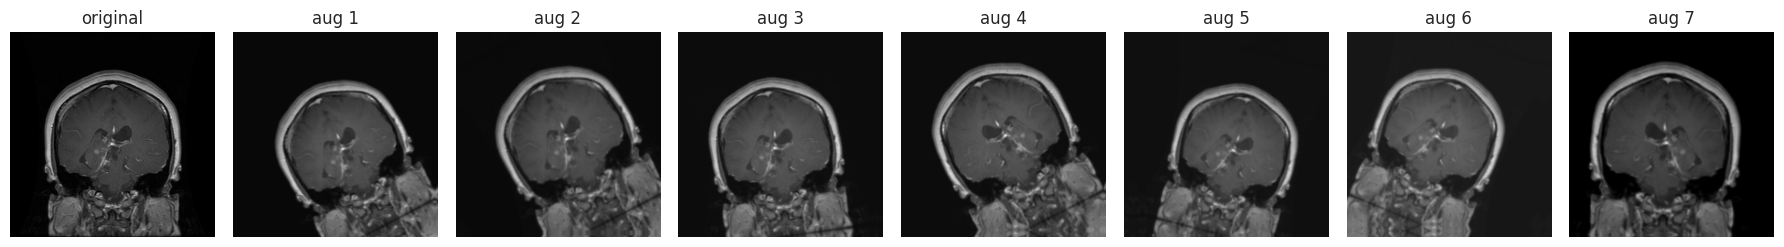

In [17]:
# Visualise augmentation: one training image, 7 random augmentations
img_batch, _ = next(iter(ds_val))
sample = img_batch[0:1]
fig, axes = plt.subplots(1, 8, figsize=(18, 2.8))
axes[0].imshow(sample[0].numpy().astype("uint8")); axes[0].set_title("original"); axes[0].axis("off")
for i in range(1, 8):
    aug = augment(sample, training=True)
    aug = tf.clip_by_value(tf.image.random_brightness(aug[0], 25.0), 0, 255).numpy().astype("uint8")
    axes[i].imshow(aug); axes[i].set_title(f"aug {i}"); axes[i].axis("off")
plt.tight_layout(); plt.show()

## ***5. Model Building***
### Shared helpers (callbacks, training, plotting, evaluation)

In [18]:
def get_callbacks(ckpt_path, threshold=None, patience=6):
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True,
                                        initial_value_threshold=threshold, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ]

def compile_model(model, lr):
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

def merge_histories(*hists):
    out = {}
    for h in hists:
        for k, v in h.history.items():
            out.setdefault(k, []).extend(v)
    return out

def plot_history(hist, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["accuracy"], label="train"); ax[0].plot(hist["val_accuracy"], label="validation")
    ax[0].set_title(f"{title} - accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(hist["loss"], label="train"); ax[1].plot(hist["val_loss"], label="validation")
    ax[1].set_title(f"{title} - loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

results, histories = {}, {}

def evaluate_model(name, ckpt_path):
    # Reload the best checkpoint from disk and score it on the untouched test split.
    model = keras.models.load_model(ckpt_path)
    t0 = time.time(); probs = model.predict(ds_test, verbose=0); dt = time.time() - t0
    y_pred = probs.argmax(1)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    per_class_recall = precision_recall_fscore_support(y_test, y_pred, labels=np.arange(NUM_CLASSES), zero_division=0)[1]
    tumor_mask = y_test != CLASS_TO_ID["no_tumor"]
    tumor_miss = float(np.mean(y_pred[tumor_mask] == CLASS_TO_ID["no_tumor"]) * 100)   # tumor predicted as "no tumor"
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred), "Macro Precision": p, "Macro Recall": r, "Macro F1": f1,
        "Tumor missed as No-Tumor (%)": tumor_miss,
        "Params (M)": model.count_params() / 1e6,
        "Size (MB)": os.path.getsize(ckpt_path) / 1e6,
        "Inference (ms/img)": 1000 * dt / len(y_test),
        "_y_pred": y_pred, "_probs": probs, "_recall": per_class_recall, "_ckpt": ckpt_path,
    }
    print(f"\n===== {name} : test results =====")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))
    return model

### Model 1 - Custom CNN (from scratch)
Four convolution blocks (two 3x3 convs + BatchNorm + ReLU, then max-pool), global average pooling, Dropout, a dense layer with Dropout, and a softmax output. BatchNormalization stabilises training, Dropout fights overfitting on this small dataset.

**Design note (learned from a failed first attempt):** the first version had Dropout between the conv blocks, i.e. right before the next BatchNormalization. Training accuracy rose to 78% while validation accuracy stayed stuck at ~33% (the model predicted almost everything as glioma). Dropout in front of BatchNorm changes the activation variance between training and inference, so BN's running statistics do not match what the model sees at test time. Fix: Dropout only after global pooling (where no BatchNorm follows), and BatchNorm momentum 0.9 so its running statistics adapt faster.

In [19]:
def build_custom_cnn():
    inp = keras.Input(shape=(*IMG_SIZE, 3))
    x = augment(inp)
    x = layers.Rescaling(1.0 / 255)(x)                            # 0-1 normalisation
    for filters in (32, 64, 128, 256):
        for _ in range(2):
            x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
            x = layers.BatchNormalization(momentum=0.9)(x)
            x = layers.ReLU()(x)
        x = layers.MaxPooling2D()(x)                              # no Dropout here (it sits before the next BatchNorm)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name="custom_cnn")

cnn = build_custom_cnn()
compile_model(cnn, LR_CNN)
cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,241,956 (4.74 MB)

 Trainable params: 1,240,036 (4.73 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/60


50/50 - 28s - 556ms/step - accuracy: 0.5201 - loss: 1.1747 - val_accuracy: 0.5876 - val_loss: 0.9132 - learning_rate: 0.0010
Epoch 2/60
50/50 - 13s - 268ms/step - accuracy: 0.6155 - loss: 0.9827 - val_accuracy: 0.3840 - val_loss: 1.7198 - learning_rate: 0.0010
Epoch 3/60
50/50 - 14s - 273ms/step - accuracy: 0.6454 - loss: 0.9076 - val_accuracy: 0.2629 - val_loss: 3.8963 - learning_rate: 0.0010
Epoch 4/60


50/50 - 14s - 278ms/step - accuracy: 0.6365 - loss: 0.9293 - val_accuracy: 0.7526 - val_loss: 0.7038 - learning_rate: 0.0010
Epoch 5/60


50/50 - 14s - 281ms/step - accuracy: 0.6633 - loss: 0.8687 - val_accuracy: 0.7577 - val_loss: 0.6268 - learning_rate: 0.0010
Epoch 6/60
50/50 - 14s - 283ms/step - accuracy: 0.6906 - loss: 0.8043 - val_accuracy: 0.4536 - val_loss: 2.6653 - learning_rate: 0.0010
Epoch 7/60
50/50 - 14s - 282ms/step - accuracy: 0.7129 - loss: 0.7856 - val_accuracy: 0.6005 - val_loss: 0.8868 - learning_rate: 0.0010
Epoch 8/60

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
50/50 - 14s - 279ms/step - accuracy: 0.6906 - loss: 0.8148 - val_accuracy: 0.6443 - val_loss: 1.0299 - learning_rate: 0.0010
Epoch 9/60


50/50 - 14s - 280ms/step - accuracy: 0.7454 - loss: 0.6815 - val_accuracy: 0.8119 - val_loss: 0.4750 - learning_rate: 3.0000e-04
Epoch 10/60
50/50 - 14s - 277ms/step - accuracy: 0.7651 - loss: 0.6258 - val_accuracy: 0.7500 - val_loss: 0.6498 - learning_rate: 3.0000e-04
Epoch 11/60
50/50 - 14s - 279ms/step - accuracy: 0.7740 - loss: 0.5949 - val_accuracy: 0.7629 - val_loss: 0.5887 - learning_rate: 3.0000e-04
Epoch 12/60

Epoch 12: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
50/50 - 14s - 280ms/step - accuracy: 0.7995 - loss: 0.5506 - val_accuracy: 0.7423 - val_loss: 0.5935 - learning_rate: 3.0000e-04
Epoch 13/60
50/50 - 14s - 281ms/step - accuracy: 0.7849 - loss: 0.5461 - val_accuracy: 0.7784 - val_loss: 0.5088 - learning_rate: 9.0000e-05
Epoch 14/60
50/50 - 14s - 280ms/step - accuracy: 0.8154 - loss: 0.5020 - val_accuracy: 0.7887 - val_loss: 0.5337 - learning_rate: 9.0000e-05
Epoch 15/60

Epoch 15: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05

50/50 - 14s - 282ms/step - accuracy: 0.8294 - loss: 0.4980 - val_accuracy: 0.8222 - val_loss: 0.4630 - learning_rate: 2.7000e-05
Epoch 17/60
50/50 - 14s - 280ms/step - accuracy: 0.8269 - loss: 0.4855 - val_accuracy: 0.8170 - val_loss: 0.4654 - learning_rate: 2.7000e-05
Epoch 18/60
50/50 - 14s - 280ms/step - accuracy: 0.8180 - loss: 0.4915 - val_accuracy: 0.7835 - val_loss: 0.5114 - learning_rate: 2.7000e-05
Epoch 19/60

Epoch 19: ReduceLROnPlateau reducing learning rate to 8.100000013655517e-06.
50/50 - 14s - 280ms/step - accuracy: 0.8230 - loss: 0.4825 - val_accuracy: 0.7809 - val_loss: 0.4936 - learning_rate: 2.7000e-05
Epoch 20/60
50/50 - 14s - 281ms/step - accuracy: 0.8160 - loss: 0.5004 - val_accuracy: 0.7706 - val_loss: 0.5117 - learning_rate: 8.1000e-06
Epoch 21/60


50/50 - 14s - 283ms/step - accuracy: 0.8332 - loss: 0.4762 - val_accuracy: 0.8170 - val_loss: 0.4563 - learning_rate: 8.1000e-06
Epoch 22/60
50/50 - 14s - 281ms/step - accuracy: 0.8224 - loss: 0.4788 - val_accuracy: 0.7706 - val_loss: 0.5257 - learning_rate: 8.1000e-06
Epoch 23/60
50/50 - 14s - 280ms/step - accuracy: 0.8262 - loss: 0.4831 - val_accuracy: 0.7861 - val_loss: 0.4818 - learning_rate: 8.1000e-06
Epoch 24/60

Epoch 24: ReduceLROnPlateau reducing learning rate to 2.429999949526973e-06.
50/50 - 14s - 280ms/step - accuracy: 0.8230 - loss: 0.4664 - val_accuracy: 0.7809 - val_loss: 0.5035 - learning_rate: 8.1000e-06
Epoch 25/60


50/50 - 14s - 283ms/step - accuracy: 0.8186 - loss: 0.4969 - val_accuracy: 0.8222 - val_loss: 0.4436 - learning_rate: 2.4300e-06
Epoch 26/60
50/50 - 14s - 280ms/step - accuracy: 0.8224 - loss: 0.4784 - val_accuracy: 0.7784 - val_loss: 0.5177 - learning_rate: 2.4300e-06
Epoch 27/60
50/50 - 14s - 280ms/step - accuracy: 0.8402 - loss: 0.4725 - val_accuracy: 0.7809 - val_loss: 0.4978 - learning_rate: 2.4300e-06
Epoch 28/60

Epoch 28: ReduceLROnPlateau reducing learning rate to 7.289999985005124e-07.
50/50 - 14s - 280ms/step - accuracy: 0.8275 - loss: 0.4828 - val_accuracy: 0.7861 - val_loss: 0.4935 - learning_rate: 2.4300e-06
Epoch 29/60
50/50 - 14s - 280ms/step - accuracy: 0.8243 - loss: 0.4643 - val_accuracy: 0.7577 - val_loss: 0.5399 - learning_rate: 7.2900e-07
Epoch 30/60
50/50 - 14s - 280ms/step - accuracy: 0.8250 - loss: 0.4850 - val_accuracy: 0.7809 - val_loss: 0.5151 - learning_rate: 7.2900e-07
Epoch 31/60

Epoch 31: ReduceLROnPlateau reducing learning rate to 2.1870000637136398e-0

50/50 - 14s - 283ms/step - accuracy: 0.8097 - loss: 0.4972 - val_accuracy: 0.8273 - val_loss: 0.4226 - learning_rate: 2.1870e-07
Epoch 33/60
50/50 - 14s - 281ms/step - accuracy: 0.8351 - loss: 0.4570 - val_accuracy: 0.7861 - val_loss: 0.5200 - learning_rate: 2.1870e-07
Epoch 34/60
50/50 - 14s - 280ms/step - accuracy: 0.8160 - loss: 0.4812 - val_accuracy: 0.7835 - val_loss: 0.4989 - learning_rate: 2.1870e-07
Epoch 35/60

Epoch 35: ReduceLROnPlateau reducing learning rate to 1e-07.
50/50 - 14s - 281ms/step - accuracy: 0.8218 - loss: 0.4634 - val_accuracy: 0.8015 - val_loss: 0.4919 - learning_rate: 2.1870e-07
Epoch 36/60
50/50 - 14s - 280ms/step - accuracy: 0.8307 - loss: 0.4738 - val_accuracy: 0.8196 - val_loss: 0.4627 - learning_rate: 1.0000e-07
Epoch 37/60
50/50 - 14s - 280ms/step - accuracy: 0.8250 - loss: 0.4699 - val_accuracy: 0.8119 - val_loss: 0.4543 - learning_rate: 1.0000e-07
Epoch 38/60
50/50 - 14s - 280ms/step - accuracy: 0.8536 - loss: 0.4467 - val_accuracy: 0.7990 - val_loss

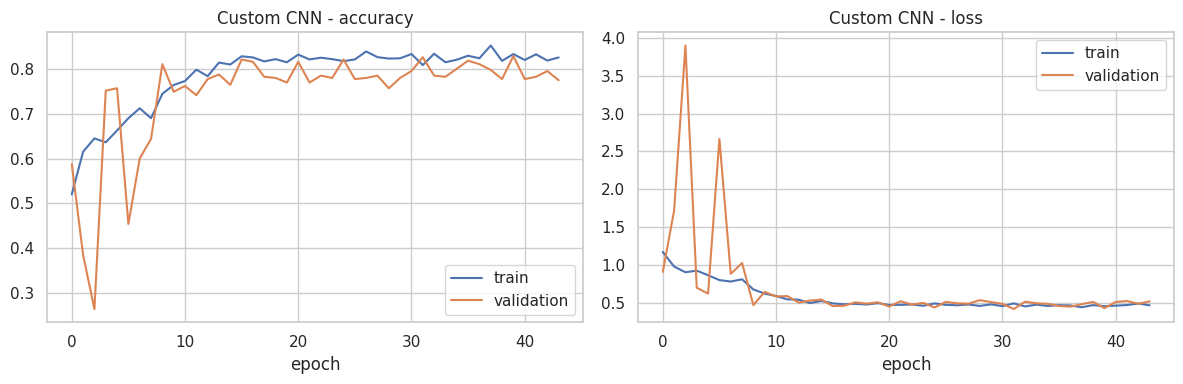


===== Custom CNN : test results =====
              precision    recall  f1-score   support

      glioma      0.948     0.821     0.880       156
  meningioma      0.791     0.482     0.599       110
    no_tumor      0.783     0.874     0.826        95
   pituitary      0.688     0.984     0.809       123

    accuracy                          0.795       484
   macro avg      0.802     0.790     0.778       484
weighted avg      0.814     0.795     0.787       484



In [20]:
CKPT_CNN = os.path.join(OUT_DIR, "custom_cnn.h5")
h = cnn.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_CNN, class_weight=class_weight,
            callbacks=get_callbacks(CKPT_CNN, patience=12), verbose=2)
histories["Custom CNN"] = merge_histories(h)
plot_history(histories["Custom CNN"], "Custom CNN")
evaluate_model("Custom CNN", CKPT_CNN);

### Models 2-4 - Transfer learning (MobileNetV2, EfficientNetB0, ResNet50V2)
Each backbone is loaded with ImageNet weights and its top removed. We add global average pooling, Dropout, a dense layer and a new 4-class softmax head.

- **Phase 1:** backbone frozen, only the new head is trained (learning rate 1e-3).
- **Phase 2:** the top `UNFREEZE_LAST` backbone layers are unfrozen (BatchNorm layers stay frozen, which is the standard safe practice) and trained at a very low learning rate (1e-5) so pretrained features are adapted, not destroyed.

ResNet50V2 is used instead of the original ResNet50 because its input scaling (-1..1) can be expressed with a plain `Rescaling` layer, which keeps the saved `.h5` loadable anywhere without custom code.

In [21]:
TL_SPECS = {
    "MobileNetV2":    {"fn": keras.applications.MobileNetV2,    "scale": "minus1_1"},
    "EfficientNetB0": {"fn": keras.applications.EfficientNetB0, "scale": None},   # rescales internally (expects 0-255)
    "ResNet50V2":     {"fn": keras.applications.ResNet50V2,     "scale": "minus1_1"},
}

def build_transfer_model(name):
    spec = TL_SPECS[name]
    base = spec["fn"](include_top=False, weights=WEIGHTS, input_shape=(*IMG_SIZE, 3))
    base.trainable = False
    inp = keras.Input(shape=(*IMG_SIZE, 3))
    x = augment(inp)
    if spec["scale"] == "minus1_1":
        x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)
    x = base(x, training=False)                                   # keep BatchNorm in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name=name.lower()), base

def train_transfer_model(name):
    model, base = build_transfer_model(name)
    ckpt = os.path.join(OUT_DIR, f"{name.lower()}.h5")

    # Phase 1: train the new head only
    compile_model(model, LR_HEAD)
    h1 = model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_HEAD, class_weight=class_weight,
                   callbacks=get_callbacks(ckpt, patience=4), verbose=2)
    best_val_phase1 = min(h1.history["val_loss"])

    # Phase 2: fine-tune top layers of the backbone (BatchNorm stays frozen)
    base.trainable = True
    for layer in base.layers[:-UNFREEZE_LAST]:
        layer.trainable = False
    for layer in base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    compile_model(model, LR_FINETUNE)                              # must recompile after changing trainable
    h2 = model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_FINETUNE, class_weight=class_weight,
                   callbacks=get_callbacks(ckpt, threshold=best_val_phase1, patience=5), verbose=2)

    histories[name] = merge_histories(h1, h2)
    print(f"{name}: phase 1 ran {len(h1.history['loss'])} epochs, phase 2 ran {len(h2.history['loss'])} epochs")
    plot_history(histories[name], name)
    return ckpt

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/12


50/50 - 11s - 221ms/step - accuracy: 0.6582 - loss: 0.8878 - val_accuracy: 0.7938 - val_loss: 0.5233 - learning_rate: 0.0010
Epoch 2/12
50/50 - 3s - 67ms/step - accuracy: 0.8141 - loss: 0.5041 - val_accuracy: 0.7603 - val_loss: 0.6288 - learning_rate: 0.0010
Epoch 3/12


50/50 - 4s - 75ms/step - accuracy: 0.8180 - loss: 0.4624 - val_accuracy: 0.8273 - val_loss: 0.4629 - learning_rate: 0.0010
Epoch 4/12


50/50 - 4s - 74ms/step - accuracy: 0.8421 - loss: 0.4160 - val_accuracy: 0.8325 - val_loss: 0.4138 - learning_rate: 0.0010
Epoch 5/12
50/50 - 3s - 68ms/step - accuracy: 0.8581 - loss: 0.3952 - val_accuracy: 0.8170 - val_loss: 0.4711 - learning_rate: 0.0010
Epoch 6/12
50/50 - 3s - 69ms/step - accuracy: 0.8574 - loss: 0.3624 - val_accuracy: 0.8428 - val_loss: 0.4266 - learning_rate: 0.0010
Epoch 7/12

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
50/50 - 3s - 68ms/step - accuracy: 0.8727 - loss: 0.3554 - val_accuracy: 0.8144 - val_loss: 0.4542 - learning_rate: 0.0010
Epoch 8/12
50/50 - 3s - 69ms/step - accuracy: 0.8950 - loss: 0.2949 - val_accuracy: 0.7938 - val_loss: 0.4813 - learning_rate: 3.0000e-04
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 4.
Epoch 1/15
50/50 - 11s - 223ms/step - accuracy: 0.8759 - loss: 0.3469 - val_accuracy: 0.7809 - val_loss: 0.5274 - learning_rate: 1.0000e-05
Epoch 2/15
50/50 - 4s - 75ms/step - a

50/50 - 4s - 83ms/step - accuracy: 0.9090 - loss: 0.2617 - val_accuracy: 0.8711 - val_loss: 0.3663 - learning_rate: 1.0000e-05
Epoch 6/15
50/50 - 4s - 75ms/step - accuracy: 0.9147 - loss: 0.2484 - val_accuracy: 0.8634 - val_loss: 0.3944 - learning_rate: 1.0000e-05
Epoch 7/15
50/50 - 4s - 74ms/step - accuracy: 0.9115 - loss: 0.2416 - val_accuracy: 0.8582 - val_loss: 0.3939 - learning_rate: 1.0000e-05
Epoch 8/15

Epoch 8: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
50/50 - 4s - 75ms/step - accuracy: 0.9166 - loss: 0.2484 - val_accuracy: 0.8454 - val_loss: 0.4387 - learning_rate: 1.0000e-05
Epoch 9/15
50/50 - 4s - 74ms/step - accuracy: 0.9306 - loss: 0.1987 - val_accuracy: 0.8479 - val_loss: 0.4271 - learning_rate: 3.0000e-06
Epoch 10/15
50/50 - 4s - 75ms/step - accuracy: 0.9325 - loss: 0.2041 - val_accuracy: 0.8454 - val_loss: 0.4378 - learning_rate: 3.0000e-06
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.
MobileNetV2: phase 1

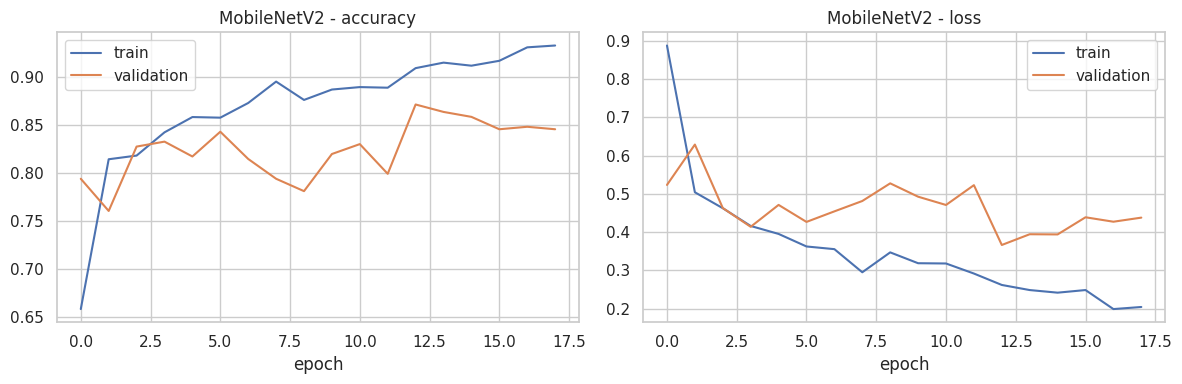


===== MobileNetV2 : test results =====
              precision    recall  f1-score   support

      glioma      0.963     0.827     0.890       156
  meningioma      0.726     0.627     0.673       110
    no_tumor      0.922     0.874     0.897        95
   pituitary      0.739     0.992     0.847       123

    accuracy                          0.833       484
   macro avg      0.838     0.830     0.827       484
weighted avg      0.844     0.833     0.831       484



In [26]:
# Model 2: MobileNetV2
ckpt = train_transfer_model("MobileNetV2")
evaluate_model("MobileNetV2", ckpt);

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/12


E0000 00:00:1791188028.103695      49 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


50/50 - 17s - 349ms/step - accuracy: 0.6773 - loss: 0.8459 - val_accuracy: 0.7371 - val_loss: 0.6333 - learning_rate: 0.0010
Epoch 2/12
50/50 - 5s - 90ms/step - accuracy: 0.8109 - loss: 0.5126 - val_accuracy: 0.7191 - val_loss: 0.7065 - learning_rate: 0.0010
Epoch 3/12
50/50 - 5s - 90ms/step - accuracy: 0.8345 - loss: 0.4503 - val_accuracy: 0.7191 - val_loss: 0.7337 - learning_rate: 0.0010
Epoch 4/12

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
50/50 - 5s - 92ms/step - accuracy: 0.8574 - loss: 0.4000 - val_accuracy: 0.7088 - val_loss: 0.8060 - learning_rate: 0.0010
Epoch 5/12


50/50 - 5s - 101ms/step - accuracy: 0.8701 - loss: 0.3833 - val_accuracy: 0.7784 - val_loss: 0.5863 - learning_rate: 3.0000e-04
Epoch 6/12


50/50 - 5s - 102ms/step - accuracy: 0.8848 - loss: 0.3445 - val_accuracy: 0.7784 - val_loss: 0.5788 - learning_rate: 3.0000e-04
Epoch 7/12


...

50/50 - 19s - 372ms/step - accuracy: 0.8975 - loss: 0.3021 - val_accuracy: 0.8015 - val_loss: 0.5353 - learning_rate: 1.0000e-05
Epoch 2/15
50/50 - 5s - 96ms/step - accuracy: 0.9020 - loss: 0.2897 - val_accuracy: 0.8119 - val_loss: 0.5473 - learning_rate: 1.0000e-05
Epoch 3/15


50/50 - 5s - 108ms/step - accuracy: 0.9013 - loss: 0.2782 - val_accuracy: 0.8351 - val_loss: 0.4955 - learning_rate: 1.0000e-05
Epoch 4/15


50/50 - 5s - 108ms/step - accuracy: 0.9007 - loss: 0.2773 - val_accuracy: 0.8351 - val_loss: 0.4883 - learning_rate: 1.0000e-05
Epoch 5/15
50/50 - 5s - 99ms/step - accuracy: 0.8912 - loss: 0.2996 - val_accuracy: 0.8196 - val_loss: 0.5343 - learning_rate: 1.0000e-05
Epoch 6/15
50/50 - 5s - 99ms/step - accuracy: 0.9122 - loss: 0.2685 - val_accuracy: 0.8222 - val_loss: 0.5259 - learning_rate: 1.0000e-05
Epoch 7/15

Epoch 7: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
50/50 - 5s - 99ms/step - accuracy: 0.9032 - loss: 0.2737 - val_accuracy: 0.8376 - val_loss: 0.4946 - learning_rate: 1.0000e-05
Epoch 8/15


50/50 - 6s - 110ms/step - accuracy: 0.9064 - loss: 0.2556 - val_accuracy: 0.8402 - val_loss: 0.4818 - learning_rate: 3.0000e-06
Epoch 9/15


50/50 - 5s - 109ms/step - accuracy: 0.9115 - loss: 0.2596 - val_accuracy: 0.8376 - val_loss: 0.4703 - learning_rate: 3.0000e-06
Epoch 10/15
50/50 - 5s - 99ms/step - accuracy: 0.9039 - loss: 0.2411 - val_accuracy: 0.8376 - val_loss: 0.4722 - learning_rate: 3.0000e-06
Epoch 11/15
50/50 - 5s - 98ms/step - accuracy: 0.9013 - loss: 0.2625 - val_accuracy: 0.8376 - val_loss: 0.4714 - learning_rate: 3.0000e-06
Epoch 12/15

Epoch 12: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
50/50 - 5s - 98ms/step - accuracy: 0.9077 - loss: 0.2605 - val_accuracy: 0.8428 - val_loss: 0.4876 - learning_rate: 3.0000e-06
Epoch 13/15
50/50 - 5s - 97ms/step - accuracy: 0.9141 - loss: 0.2545 - val_accuracy: 0.8428 - val_loss: 0.4918 - learning_rate: 9.0000e-07
Epoch 14/15
50/50 - 5s - 98ms/step - accuracy: 0.9020 - loss: 0.2713 - val_accuracy: 0.8428 - val_loss: 0.4923 - learning_rate: 9.0000e-07
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 9.
EfficientNetB0:

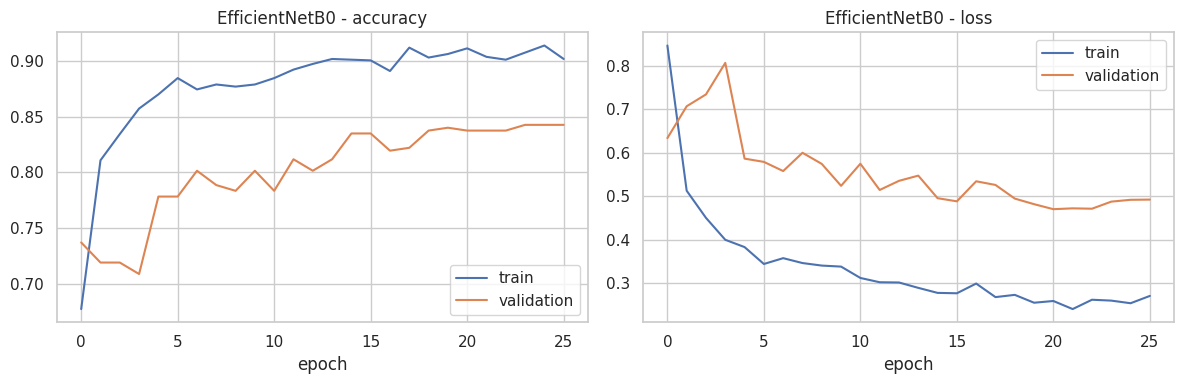


===== EfficientNetB0 : test results =====
              precision    recall  f1-score   support

      glioma      0.631     0.974     0.766       156
  meningioma      0.804     0.373     0.509       110
    no_tumor      0.975     0.821     0.891        95
   pituitary      0.839     0.764     0.800       123

    accuracy                          0.754       484
   macro avg      0.812     0.733     0.742       484
weighted avg      0.791     0.754     0.741       484



In [27]:
# Model 3: EfficientNetB0
ckpt = train_transfer_model("EfficientNetB0")
evaluate_model("EfficientNetB0", ckpt);

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/12


50/50 - 18s - 354ms/step - accuracy: 0.6951 - loss: 0.8316 - val_accuracy: 0.7784 - val_loss: 0.5518 - learning_rate: 0.0010
Epoch 2/12


50/50 - 7s - 145ms/step - accuracy: 0.8071 - loss: 0.5330 - val_accuracy: 0.8325 - val_loss: 0.4624 - learning_rate: 0.0010
Epoch 3/12


50/50 - 7s - 147ms/step - accuracy: 0.8173 - loss: 0.4806 - val_accuracy: 0.8196 - val_loss: 0.4509 - learning_rate: 0.0010
Epoch 4/12
50/50 - 7s - 138ms/step - accuracy: 0.8561 - loss: 0.4106 - val_accuracy: 0.8119 - val_loss: 0.5146 - learning_rate: 0.0010
Epoch 5/12


50/50 - 7s - 150ms/step - accuracy: 0.8612 - loss: 0.3769 - val_accuracy: 0.8840 - val_loss: 0.3520 - learning_rate: 0.0010
Epoch 6/12
50/50 - 7s - 139ms/step - accuracy: 0.8714 - loss: 0.3540 - val_accuracy: 0.8376 - val_loss: 0.4788 - learning_rate: 0.0010
Epoch 7/12


...

50/50 - 7s - 145ms/step - accuracy: 0.8816 - loss: 0.3025 - val_accuracy: 0.8892 - val_loss: 0.3096 - learning_rate: 0.0010
Epoch 11/12


50/50 - 7s - 146ms/step - accuracy: 0.9007 - loss: 0.2797 - val_accuracy: 0.9253 - val_loss: 0.2718 - learning_rate: 0.0010
Epoch 12/12
50/50 - 7s - 135ms/step - accuracy: 0.8892 - loss: 0.3023 - val_accuracy: 0.9046 - val_loss: 0.2813 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 11.
Epoch 1/15
50/50 - 18s - 369ms/step - accuracy: 0.9013 - loss: 0.2765 - val_accuracy: 0.8892 - val_loss: 0.3157 - learning_rate: 1.0000e-05
Epoch 2/15
50/50 - 9s - 172ms/step - accuracy: 0.9179 - loss: 0.2188 - val_accuracy: 0.9072 - val_loss: 0.2927 - learning_rate: 1.0000e-05
Epoch 3/15
50/50 - 10s - 196ms/step - accuracy: 0.9332 - loss: 0.1832 - val_accuracy: 0.9046 - val_loss: 0.3349 - learning_rate: 1.0000e-05
Epoch 4/15


50/50 - 9s - 188ms/step - accuracy: 0.9357 - loss: 0.1880 - val_accuracy: 0.9381 - val_loss: 0.2264 - learning_rate: 1.0000e-05
Epoch 5/15
50/50 - 9s - 173ms/step - accuracy: 0.9510 - loss: 0.1359 - val_accuracy: 0.9356 - val_loss: 0.2383 - learning_rate: 1.0000e-05
Epoch 6/15
50/50 - 9s - 171ms/step - accuracy: 0.9516 - loss: 0.1335 - val_accuracy: 0.9304 - val_loss: 0.2560 - learning_rate: 1.0000e-05
Epoch 7/15


50/50 - 9s - 184ms/step - accuracy: 0.9504 - loss: 0.1403 - val_accuracy: 0.9227 - val_loss: 0.2222 - learning_rate: 1.0000e-05
Epoch 8/15
50/50 - 8s - 169ms/step - accuracy: 0.9574 - loss: 0.1119 - val_accuracy: 0.9175 - val_loss: 0.2627 - learning_rate: 1.0000e-05
Epoch 9/15
50/50 - 8s - 168ms/step - accuracy: 0.9605 - loss: 0.1097 - val_accuracy: 0.9227 - val_loss: 0.2286 - learning_rate: 1.0000e-05
Epoch 10/15

Epoch 10: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
50/50 - 8s - 169ms/step - accuracy: 0.9733 - loss: 0.0893 - val_accuracy: 0.9253 - val_loss: 0.2275 - learning_rate: 1.0000e-05
Epoch 11/15
50/50 - 10s - 194ms/step - accuracy: 0.9637 - loss: 0.0940 - val_accuracy: 0.9278 - val_loss: 0.2547 - learning_rate: 3.0000e-06
Epoch 12/15


50/50 - 9s - 185ms/step - accuracy: 0.9663 - loss: 0.0944 - val_accuracy: 0.9278 - val_loss: 0.2193 - learning_rate: 3.0000e-06
Epoch 13/15
50/50 - 9s - 170ms/step - accuracy: 0.9758 - loss: 0.0743 - val_accuracy: 0.9330 - val_loss: 0.2256 - learning_rate: 3.0000e-06
Epoch 14/15
50/50 - 9s - 172ms/step - accuracy: 0.9745 - loss: 0.0741 - val_accuracy: 0.9330 - val_loss: 0.2227 - learning_rate: 3.0000e-06
Epoch 15/15

Epoch 15: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
50/50 - 9s - 172ms/step - accuracy: 0.9784 - loss: 0.0669 - val_accuracy: 0.9304 - val_loss: 0.2630 - learning_rate: 3.0000e-06
Restoring model weights from the end of the best epoch: 12.
ResNet50V2: phase 1 ran 12 epochs, phase 2 ran 15 epochs


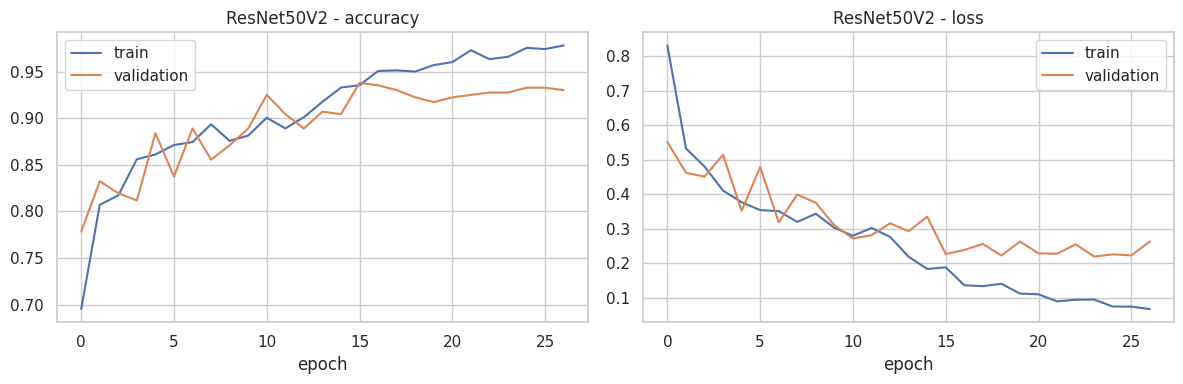


===== ResNet50V2 : test results =====
              precision    recall  f1-score   support

      glioma      0.966     0.917     0.941       156
  meningioma      0.854     0.800     0.826       110
    no_tumor      0.946     0.926     0.936        95
   pituitary      0.864     0.984     0.920       123

    accuracy                          0.909       484
   macro avg      0.908     0.907     0.906       484
weighted avg      0.911     0.909     0.909       484



In [28]:
# Model 4: ResNet50V2  (heaviest model - set BATCH_SIZE = 16 above if your GPU runs out of memory)
ckpt = train_transfer_model("ResNet50V2")
evaluate_model("ResNet50V2", ckpt);

## ***6. Model Evaluation & Comparison***
All numbers below are on the **test split**: it is never used for training, validation or early stopping, and it shares no source scan with training. It is looked at once, at the end, to compare the four finished models (with only four candidates and a single run, a small selection effect is possible, so treat the winner's score as slightly optimistic).

,Accuracy,Macro Precision,Macro Recall,Macro F1,Tumor missed as No-Tumor (%),Params (M),Size (MB),Inference (ms/img)
ResNet50V2,0.909,0.908,0.907,0.906,1.3,23.83,213.2,9.2
MobileNetV2,0.833,0.838,0.830,0.827,1.8,2.42,23.5,7.1
Custom CNN,0.795,0.802,0.790,0.778,5.9,1.24,15.0,3.8
EfficientNetB0,0.754,0.812,0.733,0.742,0.5,4.21,30.5,10.7


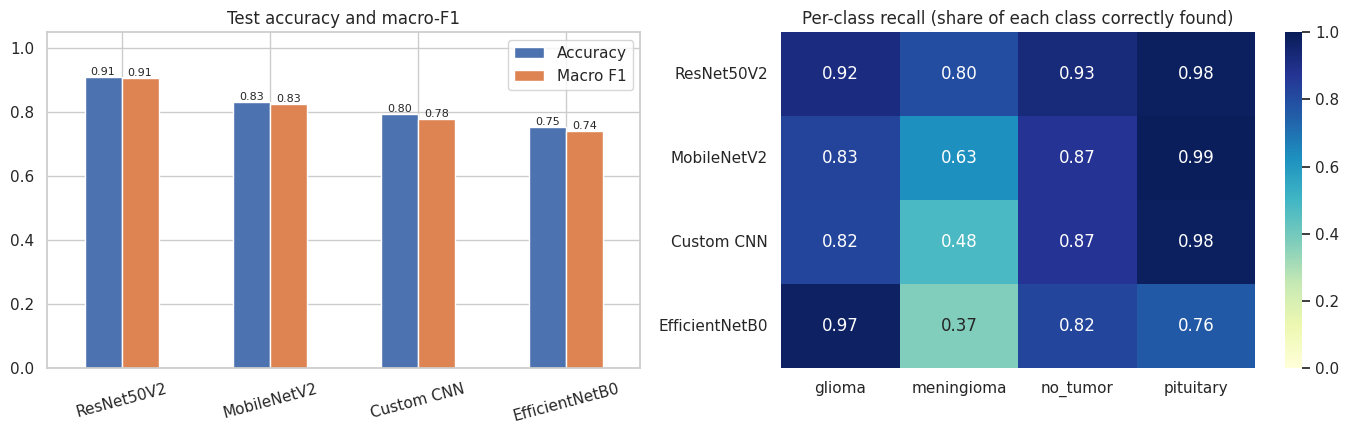

In [29]:
metric_cols = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Tumor missed as No-Tumor (%)",
               "Params (M)", "Size (MB)", "Inference (ms/img)"]
comparison = pd.DataFrame({k: {c: v[c] for c in metric_cols} for k, v in results.items()}).T
comparison = comparison.sort_values("Macro F1", ascending=False)
display(comparison.style.format({"Accuracy": "{:.3f}", "Macro Precision": "{:.3f}", "Macro Recall": "{:.3f}",
                                 "Macro F1": "{:.3f}", "Tumor missed as No-Tumor (%)": "{:.1f}",
                                 "Params (M)": "{:.2f}", "Size (MB)": "{:.1f}", "Inference (ms/img)": "{:.1f}"})
        .background_gradient(subset=["Macro F1"], cmap="Greens"))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
comparison[["Accuracy", "Macro F1"]].plot(kind="bar", ax=ax[0], rot=15)
ax[0].set_title("Test accuracy and macro-F1"); ax[0].set_ylim(0, 1.05)
for c in ax[0].containers: ax[0].bar_label(c, fmt="%.2f", fontsize=8)
recall_df = pd.DataFrame({k: v["_recall"] for k, v in results.items()}, index=CLASS_NAMES).T.loc[comparison.index]
sns.heatmap(recall_df, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, ax=ax[1])
ax[1].set_title("Per-class recall (share of each class correctly found)")
plt.tight_layout(); plt.show()

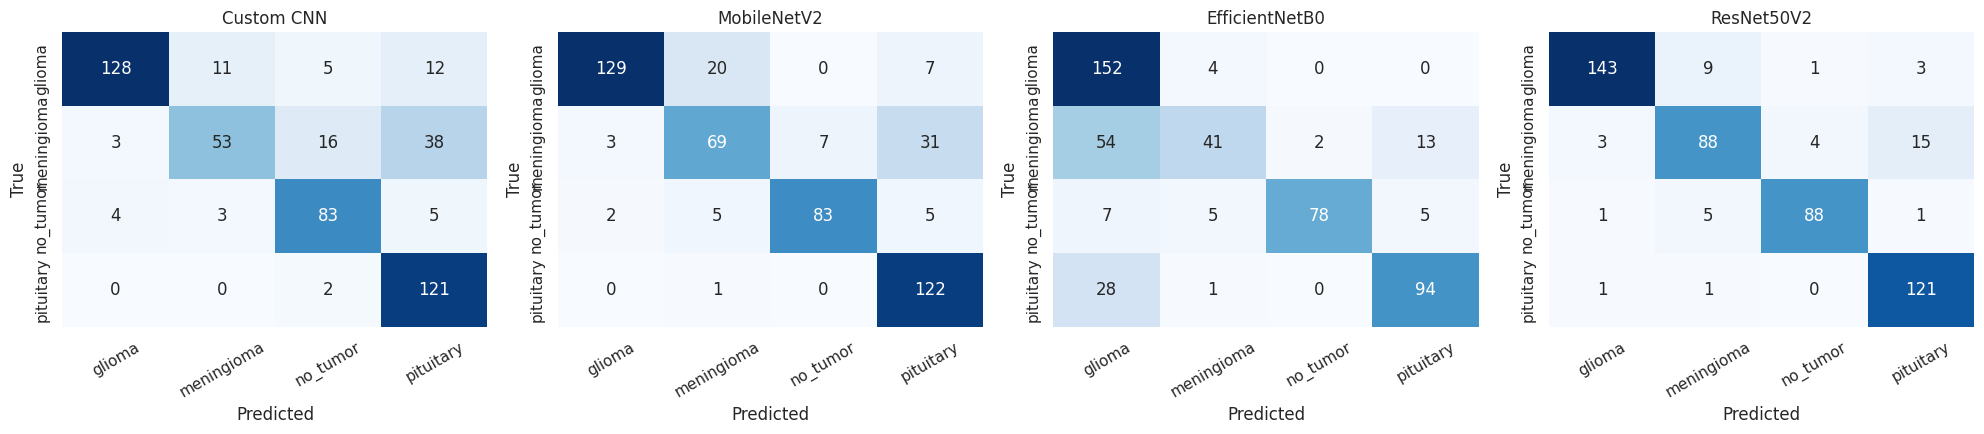

In [30]:
# Confusion matrices for every model
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))
axes = np.atleast_1d(axes)
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["_y_pred"], labels=np.arange(NUM_CLASSES))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

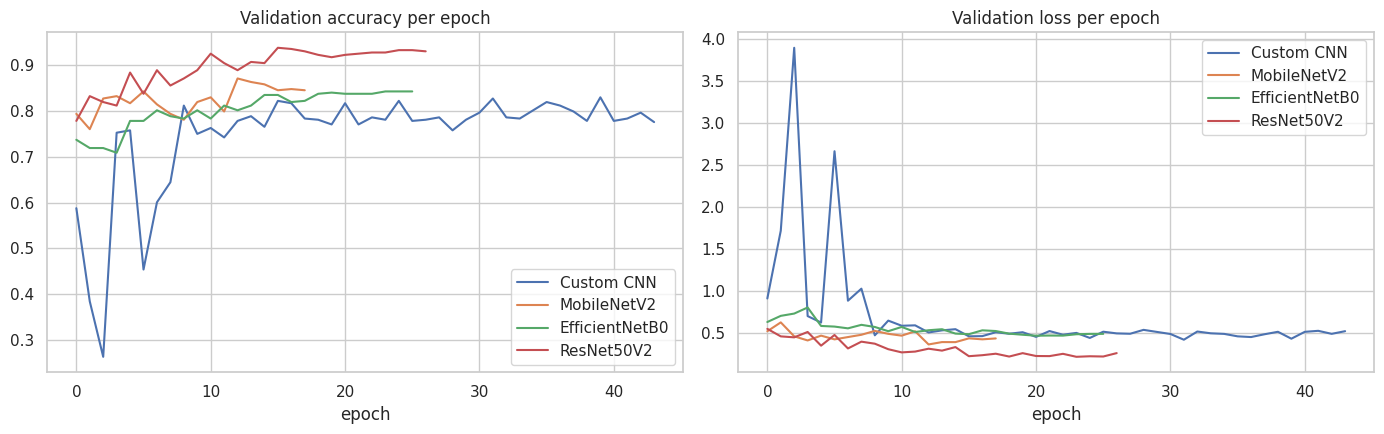

In [31]:
# Training curves of all models in one view
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, h in histories.items():
    axes[0].plot(h["val_accuracy"], label=name); axes[1].plot(h["val_loss"], label=name)
axes[0].set_title("Validation accuracy per epoch"); axes[1].set_title("Validation loss per epoch")
for a in axes: a.set_xlabel("epoch"); a.legend()
plt.tight_layout(); plt.show()

### Which metrics matter and which model do we choose?
- **Macro-F1** is the main selection metric: it treats every class equally, so the smaller classes are not drowned out by the larger ones.
- **Per-class recall** shows how many real cases of each class are found.
- **Tumor missed as No-Tumor (%)** is the clinically most dangerous error (a real tumor that the model calls healthy). Between two models with similar macro-F1, prefer the one that misses fewer tumors.
- **Size and inference time** matter for deployment (the brief asks for the most *efficient* model too). A 100 MB `.h5` also exceeds GitHub's normal file limit, so a smaller model is easier to ship.

In [35]:
# Automatic summary of the comparison (copy the conclusions into your report)
best_name = comparison.index[0]
b = comparison.loc[best_name]
print(f"Best model by macro-F1: {best_name}  (accuracy {b['Accuracy']:.3f}, macro-F1 {b['Macro F1']:.3f}, "
      f"tumor missed as no-tumor {b['Tumor missed as No-Tumor (%)']:.1f}%, size {b['Size (MB)']:.1f} MB)")
cnn_f1 = comparison.loc["Custom CNN", "Macro F1"]
tl = comparison.drop(index="Custom CNN")
print(f"Custom CNN macro-F1: {cnn_f1:.3f} | best transfer-learning macro-F1: {tl['Macro F1'].max():.3f} "
      f"({tl['Macro F1'].idxmax()}) | gap: {tl['Macro F1'].max() - cnn_f1:+.3f}")
# a model that predicts (almost) everything as one tumor class has a "perfect" tumor-miss rate, so only look at working models
working = comparison[comparison["Macro F1"] >= 0.5]
if len(working):
    print(f"Lowest tumor-miss rate among working models (macro-F1 >= 0.5): {working['Tumor missed as No-Tumor (%)'].idxmin()} "
          f"({working['Tumor missed as No-Tumor (%)'].min():.1f}%)")
else:
    print("No model reached macro-F1 >= 0.5, so the tumor-miss comparison is skipped.")
print(f"Smallest model: {comparison['Size (MB)'].idxmin()} ({comparison['Size (MB)'].min():.1f} MB)")
weakest = recall_df.loc[best_name].idxmin()
print(f"Weakest class for {best_name}: {weakest} (recall {recall_df.loc[best_name].min():.2f})")

Best model by macro-F1: ResNet50V2  (accuracy 0.909, macro-F1 0.906, tumor missed as no-tumor 1.3%, size 213.2 MB)
Custom CNN macro-F1: 0.778 | best transfer-learning macro-F1: 0.906 (ResNet50V2) | gap: +0.127
Lowest tumor-miss rate among working models (macro-F1 >= 0.5): EfficientNetB0 (0.5%)
Smallest model: Custom CNN (15.0 MB)
Weakest class for ResNet50V2: meningioma (recall 0.80)


##### Final model choice and why
**Chosen model: ResNet50V2 (fine-tuned), saved as `best_model.h5`.**

- **Best overall:** on the 484-image test split it reached 90.9% accuracy and 0.906 macro-F1, about 7 macro-F1 points above the next model (MobileNetV2, 0.827). This lead was stable: in an earlier full run ResNet50V2 scored 0.911 / 0.907, while the weaker models moved by 1 to 4 points between runs.
- **Fewest harmful mistakes among the accurate models:** only 5 of 389 tumor images (1.3%) were predicted as "no tumor". EfficientNetB0 has a lower rate (0.5%), but its accuracy is only 0.754 and it misses many meningiomas, so it is not a usable model.
- **Cost:** about 9 ms per image on a T4 GPU, and the deployed file is 95.7 MB (the 213 MB checkpoint includes optimizer state that is not needed for prediction). MobileNetV2 is much smaller (about 23 MB) but clearly less accurate, so accuracy was prioritised for a medical-imaging task.
- **Weak spots:** meningioma has the lowest recall (0.80), and 15 of 110 meningioma images were predicted as pituitary. The training accuracy (about 0.98) is higher than validation (about 0.93), so some overfitting remains.
- **Caution:** results come from a single test split of 484 images (roughly +/- 2.5 points of uncertainty) and one public dataset with no external validation. The model's confidence scores are not calibrated, and it may rely partly on scan plane or brightness (Charts 2 and 3). It is a learning project, not a medical device.

## ***7. Save the best model & sanity check***

In [37]:
best_ckpt = results[best_name]["_ckpt"]
final_path = os.path.join(OUT_DIR, "best_model.h5")

# Lean deployment model: reload best checkpoint, re-chain its layers WITHOUT the training-only
# augmentation block, save without optimizer.
loaded = keras.models.load_model(best_ckpt)
inp = keras.Input(shape=loaded.input_shape[1:])
x = inp
for layer in loaded.layers:
    if isinstance(layer, keras.layers.InputLayer) or layer.name == "augmentation":
        continue
    x = layer(x)
keras.Model(inp, x, name="best_model").save(final_path, include_optimizer=False)

with open(os.path.join(OUT_DIR, "class_names.json"), "w") as f:
    json.dump(CLASS_NAMES, f)
size_mb = os.path.getsize(final_path) / 1e6
print(f"Saved: {final_path} ({size_mb:.1f} MB)")
if size_mb > 95:
    print("WARNING: GitHub rejects files above 100 MB - use Git LFS / Hugging Face, or deploy a smaller model.")

# Sanity check: 3 unseen test images per class, same resize as training, compare with earlier predictions
reloaded = keras.models.load_model(final_path)
idx = df_test.groupby("label").head(3).index.values
batch = np.stack([tf.round(tf.image.resize(np.asarray(Image.open(p).convert("RGB")), IMG_SIZE)).numpy()
                  for p in df_test.loc[idx, "path"]]).astype("float32")
pred_ids = reloaded.predict(batch, verbose=0).argmax(1)
true_ids = df_test.loc[idx, "label_id"].values
for p, t, q in zip(df_test.loc[idx, "path"], true_ids, pred_ids):
    print(f"{os.path.basename(p)[:28]:30s} true={CLASS_NAMES[t]:11s} pred={CLASS_NAMES[q]:11s} {'OK' if t == q else 'WRONG'}")
same = (pred_ids == results[best_name]["_y_pred"][idx]).mean()
print(f"\nReloaded model agrees with the in-notebook predictions on {same*100:.0f}% of these images")

Saved: /kaggle/working/outputs/best_model.h5 (95.7 MB)


Tr-gl_0040_jpg.rf.4e8e95e2b5   true=glioma      pred=glioma      OK
Tr-gl_0124_jpg.rf.0eb7ae873c   true=glioma      pred=glioma      OK
Tr-gl_0145_jpg.rf.d3c5025136   true=glioma      pred=glioma      OK
Tr-me_0044_jpg.rf.0223369274   true=meningioma  pred=meningioma  OK
Tr-me_0084_jpg.rf.8da0909e5a   true=meningioma  pred=pituitary   WRONG
Tr-me_0088_jpg.rf.e61e56a612   true=meningioma  pred=meningioma  OK
Tr-no_0043_jpg.rf.5224aefedc   true=no_tumor    pred=no_tumor    OK
Tr-no_0055_jpg.rf.f1be184ee2   true=no_tumor    pred=no_tumor    OK
Tr-no_0139_jpg.rf.51497327a9   true=no_tumor    pred=no_tumor    OK
Tr-pi_0090_jpg.rf.c08e55649a   true=pituitary   pred=pituitary   OK
Tr-pi_0098_jpg.rf.eec9da587f   true=pituitary   pred=pituitary   OK
Tr-pi_0130_jpg.rf.15adee5c88   true=pituitary   pred=pituitary   OK

Reloaded model agrees with the in-notebook predictions on 100% of these images


I0000 00:00:1791189519.237584     149 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


## ***8. Streamlit App (separate file)***
The app lives in `app.py` (included in the project folder). Copy `best_model.h5` and `class_names.json` into a `models/` folder next to it, then run:

```
pip install -r requirements.txt
streamlit run app.py
```
It lets the user upload an MRI image, shows the predicted tumor type, the confidence, and the probability of every class.

## ***9. Limitations & Future Work***
- Only ~2.4k images, from a single public source; there is no external hospital validation, so real-world performance is unknown.
- Re-splitting by source scan removed leakage between *our* splits, but we cannot rule out that different Roboflow variants of the same patient exist under different IDs.
- Ideas: Grad-CAM heat-maps to show *where* the model looks, k-fold cross-validation for more stable estimates, test-time augmentation, and calibrating confidence scores before any clinical use.

# **Conclusion**
In this project I built a four-class brain tumor MRI classifier (glioma, meningioma, pituitary, no tumor) with a custom CNN and three ImageNet-pretrained models. I found that the provided train/valid/test folders leak data: 27% of the test images came from scans that also appear in training, so I rebuilt the split grouped by source scan (1571 / 388 / 484 images) to get honest scores. The fine-tuned ResNet50V2 was the best model with 90.9% test accuracy and 0.906 macro-F1, missing 5 of 389 tumor images, while the custom CNN reached 79.5% accuracy and 0.778 macro-F1. The custom CNN first failed (about 33% validation accuracy) and only worked after I changed the dropout placement and the BatchNorm momentum. Meningioma is the hardest class and is often confused with pituitary, and the data suggests scan plane and brightness may act as shortcuts, so real-world accuracy is likely lower than reported. The model is deployed in a Streamlit app that returns the predicted class with confidence scores, but it was trained on one small public dataset without external validation and is a learning project, not a medical tool.

### ***Hurrah! You have successfully completed your Deep Learning Capstone Project !!!***